In [1]:
import os, sys

from dotenv import load_dotenv

load_dotenv("../../.env")

# src 디렉토리를 Python path에 추가
sys.path.insert(0, os.path.abspath("../src"))

%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="LangSmith now uses UUID v7", 
    category=UserWarning,
)

# Deep Agent for Research

## Overview 

<img src="./assets/agent_header.png" width="800" style="display:block; margin-left:0;">

이제 지금까지 배운 내용을 종합해 보겠습니다:

* **TODO**를 사용하여 작업 내역을 관리할 것입니다. 
* **파일**을 사용하여 도구 호출의 원시 결과를 저장할 것입니다. 
* 컨텍스트 격리를 위해 **연구 작업을 하위 에이전트에게 위임**할 것입니다. 

## Search Tool 

원본 콘텐츠는 파일로 저장하고 에이전트에는 요약 정보만 반환하는 검색 도구를 구축할 것입니다. 이는 [Manus 사례에서 보았듯이](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus), 장시간 실행되는 에이전트 트래잭터리에 흔히 사용되는 패턴입니다! 

### Core Components

1. **검색 실행 (`run_tavily_search`)**: 결과 수 및 주제 필터링에 대한 구성 가능한 매개변수를 사용하여 Tavily API를 통해 실제 웹 검색을 수행합니다.

2. **콘텐츠 요약 (`summarize_webpage_content`)**: 경량 모델(GPT-4o-mini)을 사용하여 웹페이지 콘텐츠의 구조화된 요약을 생성하며, 설명적인 파일명과 핵심 학습 내용 요약을 모두 출력합니다.

3. **결과 처리 (`process_search_results`)**: HTTP를 통해 전체 웹페이지 콘텐츠를 가져오고, `markdownify`를 사용하여 HTML을 마크다운으로 변환하며, 각 결과에 대한 요약문을 생성합니다.

4. **컨텍스트 오프로딩 (`tavily_search` 도구)**: 다음 기능을 수행하는 주요 도구입니다:
   - 검색을 실행하고 결과를 처리합니다
   - 전체 콘텐츠를 에이전트 상태의 파일로 저장합니다(컨텍스트 오프로딩)
   - 에이전트에는 최소한의 요약만 반환합니다(컨텍스트 스팸 방지)
   - LangGraph `Command`를 사용하여 파일과 메시지를 모두 업데이트합니다

5. **전략적 사고 (`think_tool`)**: 에이전트가 연구 워크플로우에서 발견한 내용을 분석하고, 부족한 점을 평가하며, 다음 단계를 계획할 수 있도록 체계적인 성찰 메커니즘을 제공합니다.

이 아키텍처는 상세한 검색 결과를 파일에 저장함으로써 토큰 효율성 문제를 해결하는 동시에, 에이전트의 작업 컨텍스트를 최소한으로 유지하며 핵심에 집중할 수 있게 합니다.

<div style="background-color: #fff3b0; padding: 10px; border-radius: 4px;">
<b>Note:</b>  
The <code>create_react_agent</code> was moved from the LangGraph library to the LangChain library and renamed to <code>create_agent</code> in the 1.0 code release post-filming. There are slight changes to the imports and code to accommodate this. The video may display the previous configuration.
</div>

In [ ]:
%%writefile ../src/deep_agents_from_scratch/research_tools.py
"""Research Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""
import os
from datetime import datetime
import uuid, base64

import httpx
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import InjectedToolArg, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command
from markdownify import markdownify
from pydantic import BaseModel, Field
from tavily import TavilyClient
from typing_extensions import Annotated, Literal

from deep_agents_from_scratch.prompts import SUMMARIZE_WEB_SEARCH
from deep_agents_from_scratch.state import DeepAgentState

# Summarization model 
summarization_model = init_chat_model(model="anthropic:claude-sonnet-4-6")
tavily_client = TavilyClient()

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    filename: str = Field(description="Name of the file to store.")
    summary: str = Field(description="Key learnings from the webpage.")

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def run_tavily_search(
    search_query: str, 
    max_results: int = 1, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> dict:
    """Tavily API를 사용하여 단일 쿼리에 대한 검색을 수행합니다.

    Args:
        search_query: 실행할 검색 쿼리
        max_results: 쿼리당 최대 결과 수
        topic: 검색 결과에 대한 주제 필터
        include_raw_content: 웹페이지 원본 콘텐츠를 포함할지 여부

    Returns:
        검색 결과 딕셔너리
    """
    result = tavily_client.search(
        search_query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic
    )

    return result

def summarize_webpage_content(webpage_content: str) -> Summary:
    """설정된 요약 모델을 사용하여 웹 페이지 내용을 요약합니다.
    
    Args:
        webpage_content: 요약할 원본 웹 페이지 내용
        
    Returns:
        파일명과 요약 내용이 포함된 Summary 객체
    """
    try:
        # Set up structured output model for summarization
        structured_model = summarization_model.with_structured_output(Summary)
        
        # Generate summary
        summary_and_filename = structured_model.invoke([
            HumanMessage(content=SUMMARIZE_WEB_SEARCH.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        return summary_and_filename
        
    except Exception:
        # Return a basic summary object on failure
        return Summary(
            filename="search_result.md",
            summary=webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content
        )


def process_search_results(results: dict) -> list[dict]:
    """가능한 경우 내용을 요약하여 검색 결과를 처리합니다.

    Args:
        results: Tavily 검색 결과 딕셔너리

    Returns:
        요약이 포함된 처리된 결과 리스트
    """
    processed_results = []

    # Create a client for HTTP requests with timeout
    HTTPX_CLIENT = httpx.Client(timeout=30.0)  # Add 30 second timeout

    for result in results.get('results', []):

        # Get url 
        url = result['url']

        # Read url with timeout and error handling
        try:
            response = HTTPX_CLIENT.get(url)
        
            if response.status_code == 200:
                # Convert HTML to markdown
                raw_content = markdownify(response.text)
                summary_obj = summarize_webpage_content(raw_content)
            else:
                # Use Tavily's generated summary
                raw_content = result.get('raw_content', '')
                summary_obj = Summary(
                    filename="URL_error.md",
                    summary=result.get('content', 'Error reading URL; try another search.')
                )
        except (httpx.TimeoutException, httpx.RequestError) as e:
            # Handle timeout or connection errors gracefully
            raw_content = result.get('raw_content', '')
            summary_obj = Summary(
                filename="connection_error.md",
                summary=result.get('content', f'Could not fetch URL (timeout/connection error). Try another search.')
            )

        # uniquify file names
        uid = base64.urlsafe_b64encode(uuid.uuid4().bytes).rstrip(b"=").decode("ascii")[:8]
        name, ext = os.path.splitext(summary_obj.filename)
        summary_obj.filename = f"{name}_{uid}{ext}"

        processed_results.append({
            'url': result['url'],
            'title': result['title'],
            'summary': summary_obj.summary,
            'filename': summary_obj.filename,
            'raw_content': raw_content,
        })

    return processed_results


@tool(parse_docstring=True)
def tavily_search(
    query: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
    max_results: Annotated[int, InjectedToolArg] = 1,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> Command:
    """웹 검색을 수행하고 최소한의 컨텍스트만 return하고 상세 결과(results)는 파일에 저장합니다.

    웹 검색을 수행하고 전체 콘텐츠를 파일에 저장하여 컨텍스트를 오프로드합니다.
    에이전트가 다음 단계를 결정하는 데 도움이 되는 필수 정보만 return합니다.

    Args:
        query: 실행할 검색 쿼리
        state: 파일 저장을 위한 주입된 에이전트 상태
        tool_call_id: 주입된 도구 호출 식별자
        max_results: 반환할 결과의 최대 개수 (기본값: 1)
        topic: 주제 필터 - ‘general’, ‘news’ 또는 ‘finance’ (기본값: ‘general’)

    Returns:
        전체 결과(results)를 파일에 저장하고 최소한의 요약 정보를 제공하는 Command 객체
    """
    # Execute search
    search_results = run_tavily_search(
        query,
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    ) 

    # Process and summarize results
    processed_results = process_search_results(search_results)
    
    # Save each result to a file and prepare summary
    files = state.get("files", {})
    saved_files = []
    summaries = []
    
    for i, result in enumerate(processed_results):
        # Use the AI-generated filename from summarization
        filename = result['filename']
        
        # Create file content with full details
        file_content = f"""# Search Result: {result['title']}

**URL:** {result['url']}
**Query:** {query}
**Date:** {get_today_str()}

## Summary
{result['summary']}

## Raw Content
{result['raw_content'] if result['raw_content'] else 'No raw content available'}
"""
        
        files[filename] = file_content
        saved_files.append(filename)
        summaries.append(f"- {filename}: {result['summary']}...")
    
    # Create minimal summary for tool message - focus on what was collected
    summary_text = f"""🔍 Found {len(processed_results)} result(s) for '{query}':

{chr(10).join(summaries)}

Files: {', '.join(saved_files)}
💡 Use read_file() to access full details when needed."""

    return Command(
        update={
            "files": files,  # 전체 내용은 files에 저장 (중요, 컨텍스트 오프로드)
            "messages": [ # 요약 결과만 메시지로 전달
                ToolMessage(summary_text, tool_call_id=tool_call_id)
            ],
        }
    )

# 함수 본문이 단순해 보이지만(reflection 문자열을 그대로 반환), 핵심 가치는 함수가 하는 일이 아니라 LLM에게 함수를 호출하도록 강제하는 것에 있음
# 모델은 docstring을 보고:
#"검색 결과 확인 후, 다음 단계 결정 전, 공백 평가 시, 마무리 전" 등 언제 호출할지 학습
#"현재 발견 사항 / 공백 / 품질 / 전략적 결정" 의 무엇을 reflect할지 학습
@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """연구 진행 상황과 의사결정에 대한 전략적 성찰(reflection)을 돕는 도구.

    검색을 마칠 때마다 이 도구를 사용하여 결과를 분석하고 다음 단계를 체계적으로 계획하십시오.
    이를 통해 연구 흐름 속에서 의도적인 정지로(a deliberate pause) 질 높은 의사결정을 내릴 수 있습니다.

    사용 시점:
    - 검색 결과를 확인한 후: 어떤 핵심 정보를 찾았는가?
    - 다음 단계를 결정하기 전: 포괄적으로 답변하기에 충분한 정보가 있는가?
    - 연구의 공백을 평가할 때: 아직 어떤 구체적인 정보가 부족한가?
    - 연구를 마무리하기 전: 지금 완전한 답변을 제공할 수 있는가?
    - 질문의 복잡성: 검색 횟수 한도에 도달했는가?

    reflection 시 고려해야 할 사항:
    1. 현재 발견 사항 분석 - 어떤 구체적인 정보를 수집했는가?
    2. 공백 평가 - 여전히 누락된 중요한 정보는 무엇인가?
    3. 품질 평가 - 훌륭한 답변을 내놓기에 충분한 증거/예시가 있는가?
    4. 전략적 결정 - 검색을 계속해야 할까, 아니면 답변을 제공해야 할까?

    Args:
        reflection: 연구 진행 상황, 결과, 공백, 다음 단계에 대한 상세한 반성 내용

    Returns:
        의사결정을 위해 반성 내용이 기록되었음을 확인
    """        
    return f"Reflection recorded: {reflection}"

Overwriting ../src/deep_agents_from_scratch/research_tools.py


## Deep Agent

이제 지금까지 배운 내용을 모두 적용해 볼 수 있습니다: 

* researcher에게 `think_tool`과 앞서 소개한 `search_tool`을 제공합니다.
* 메인 에이전트 파일에는 도구들, `think_tool`, 그리고 `task` 도구를 제공합니다. 

In [4]:
from datetime import datetime

from IPython.display import Image, display
from langchain.chat_models import init_chat_model
#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent
from utils import show_prompt, stream_agent

from deep_agents_from_scratch.file_tools import ls, read_file, write_file
from deep_agents_from_scratch.prompts import (
    FILE_USAGE_INSTRUCTIONS,
    RESEARCHER_INSTRUCTIONS,
    SUBAGENT_USAGE_INSTRUCTIONS,
    TODO_USAGE_INSTRUCTIONS,
)
from deep_agents_from_scratch.research_tools import tavily_search, think_tool, get_today_str
from deep_agents_from_scratch.state import DeepAgentState
from deep_agents_from_scratch.task_tool import _create_task_tool
from deep_agents_from_scratch.todo_tools import write_todos, read_todos

# Create agent using create_react_agent directly
model = init_chat_model(model="anthropic:claude-sonnet-4-6", temperature=0.0)

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Tools
sub_agent_tools = [tavily_search, think_tool]
built_in_tools = [ls, read_file, write_file, write_todos, read_todos, think_tool]

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "연구 업무를 sub-agent researcher에게 위임하십시오. 이 researcher에게는 한 번에 하나의 주제만 부여하십시오.",
    "prompt": RESEARCHER_INSTRUCTIONS.format(date=get_today_str()),
    "tools": ["tavily_search", "think_tool"],
}

# Create task tool to delegate tasks to sub-agents
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)

delegation_tools = [task_tool]
all_tools = sub_agent_tools + built_in_tools + delegation_tools  # search available to main agent for trivial cases

# Build prompt
SUBAGENT_INSTRUCTIONS = SUBAGENT_USAGE_INSTRUCTIONS.format(
    max_concurrent_research_units=max_concurrent_research_units,
    max_researcher_iterations=max_researcher_iterations,
    date=datetime.now().strftime("%a %b %-d, %Y"),
)

In [5]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  당신은 사용자가 입력한 주제에 대해 연구를 수행하는 research assistant입니다. 참고로 오늘 날짜는 {date}입니다.  │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  당신의 임무는 도구를 활용하여 사용자가 입력한 주제에 대한 정보를 수집하는 것입니다.                            │
│  제공된 도구 중 어떤 것이든 사용하여 연구 질문에 답하는 데 도움이 될 자료를 찾을 수 있습니다.                   │
│  이러한 도구를 순차적으로 또는 동시에 호출할 수 있으며, 연구는 도구 호출 루프 내에서 진행됩니다.                │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  다음 두 가지 주요 도구를 사용할 수 있습니다:                                                                   │
│  1. **tavily_search**: 정보를 수집하기 위한 웹 검색 수행용                                                      │
│  2. **think_tool**: 연구 중 성찰(reflection) 및 전략적 계획 수립용                                              │
│                                                                                                                 │
│  **중요: 각 검색 후 think_tool을 사용하여 결과를 성찰하고 다음 단계를 계획하십시오**                            │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  시간 제약을 가진 실제 인간 researcher처럼 생각하십시오. 다음 단계를 따르십시오:                                │
│                                                                                                                 │
│  1. **질문을 주의 깊게 읽으십시오** - 사용자에게 필요한 구체적인 정보는 무엇인가요?                             │
│  2. **광범위한 검색부터 시작하십시오** - 먼저 폭넓고 포괄적인 검색어를 사용하십시오                             │
│  3. **검색을 마칠 때마다 잠시 멈추고 평가하십시오** - 답변하기에 충분한 정보가 있나요? 아직 부족한 점은         │
│  무엇인가요?                                                                                                    │
│  4. **정보를 수집하면서 더 구체적인 검색을 수행하세요** - 부족한 부분을 채우세요                                │
│  5. **확신 있게 답변할 수 있을 때 멈추세요** - 완벽을 추구하며 계속 검색하지 마세요                             │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **검색 도구 호출 예산** (과도한 검색 방지):                                                                    │
│  - **간단한 쿼리**: 검색 도구 호출 최대 1~2회                                                                   │
│  - **일반 쿼리**: 최대 2~3회 검색 도구 호출 사용                                                                │
│  - **매우 복잡한 쿼리**: 최대 5회 검색 도구 호출 사용                                                           │
│  - **항상 중단**: 5회 검색 도구 호출 후에도 적절한 출처를 찾을 수 없는 경우                                     │
│                                                                                                                 │
│  **다음과 같은 경우 즉시 중단**:                                                                                │
│  - 사용자의 질문에 포괄적으로 답변할 수 있을 때                                                                 │
│  - 해당 질문에 대해 3개 이상의 관련 예시/출처를 확보했을 때                                                     │
│  - 최근 2번의 검색에서 유사한 정보가 나왔을 때               

In [6]:
INSTRUCTIONS = (
    "# TODO MANAGEMENT\n"
    + TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# FILE SYSTEM USAGE\n"
    + FILE_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# SUB-AGENT DELEGATION\n"
    + SUBAGENT_INSTRUCTIONS
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # TODO MANAGEMENT                                                                                              │
│  사용자의 요청에 따라:                                                                                          │
│  1. 사용자 요청 시작 시 도구 설명에 따라 write_todos 도구를 사용하여 TODO를 생성합니다.                         │
│  2. TODO를 완료한 후에는 read_todos를 사용하여 TODO를 확인하고 계획을 상기합니다.                               │
│  3. 수행한 작업과 TODO에 대해 되돌아봅니다.                                                                     │
│  4. 작업을 완료로 표시하고 다음 TODO로 진행하십시오.                                                            │
│  5. 모든 TODO를 완료할 때까지 이 과정을 반복하십시오.                                                           │
│                                                                                                                 │
│  중요: 모든 사용자 요청에 대해 반드시 TODO로 구성된 연구 계획을 수립하고, 위의 지침에 따라 연구를               │
│  수행하십시오.                                                                                                  │
│  중요: 관리해야 할 TODO의 수를 최소화하기 위해 연구 작업을 *단일 TODO*로 묶어 처리하도록 하십시오.              │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # FILE SYSTEM USAGE                                                                                            │
│  당신은 컨텍스트를 유지하고 저장할 수 있도록 가상 파일 시스템에 접근할 수 있습니다.                             │
│                                                                                                                 │
│  ## 워크플로 프로세스                                                                                           │
│  1. **전체 파악**: 작업을 시작하기 전에 ls()를 사용하여 기존 파일을 확인합니다.                                 │
│  2. **저장**: write_file()을 사용하여 사용자의 요청을 저장하고, 나중에 사용할 수 있도록 보관합니다.             │
│  3. **조사**: 조사를 진행합니다. 검색 도구(search tool)가 파일을 생성합니다.                                    │
│  4. **읽기**: 수집한 자료가 충분하다고 판단되면, 파일을 읽고 이를 활용하여 사용자의 질문에 직접 답변합니다.     │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # SUB-AGENT DELEGATION                                                                                         │
│  당신은 sub-agent에게 업무(Task)를 위임할 수 있습니다.                                                          │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  당신의 역할은 sub-agent들에게 구체적인 연구 과제를 할당하여 연구를 총괄하는 것입니다.                          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  1. **task(description, subagent_type)**: 전문 sub-agent에게 연구 과제를 위임합니다.                            │
│     - description

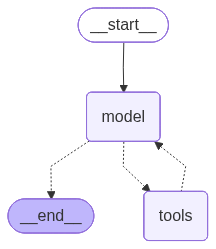

In [7]:
# Create agent
agent = create_agent(  #updated 1.0
    model, all_tools, system_prompt=INSTRUCTIONS, state_schema=DeepAgentState
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [8]:
from utils import format_messages

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Model Context Protocol(MCP)에 대해 간략히 설명해 주세요.",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Model Context Protocol(MCP)에 대해 간략히 설명해 주세요.                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Model Context Protocol(MCP) 개요 조사 및 설명 작성",                                          │
│       "status": "in_progress"                                                                                   │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: toolu_019xU3T2gMvT2RfRcBH8kJRj                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Model Context Protocol(MCP) 개요 조사 및 설명 작성', 'status':               │
│ 'in_progress'}]                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "Model Context Protocol(MCP)에 대해 다음 항목을 중심으로 조사해 주세요:\n1. MCP의 정의와       │
│ 목적\n2. MCP를 개발한 주체(개발사)\n3. MCP의 핵심 구성 요소 및 아키텍처\n4. MCP의 주요 기능과 작동 방식\n5.     │
│ MCP의 활용 사례 및 장점\n6. 최신 동향 및 지원 현황\n\n조사 결과를 findings_mcp.md 파일에 저장해 주세요.",       │
│   "subagent_type": "research-agent"                                                                             │
│ }                                                                                                               │
│    ID: toolu_01NNXYdZC3jDEqnZmSsiBoxi                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 충분한 정보가 수집되었습니다. 이제 조사 결과를 `findings_mcp.md` 파일로 정리하겠습니다.                         │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ # 📄 findings_mcp.md                                                                                            │
│                                                                                                                 │
│ ```markdown                                                                                                     │
│ # Model Context Protocol (MCP) 조사 보고서                                                                      │
│                                                                                                                 │
│ > 작성일: 2026년 5월 6일                                                                                        │
│ > 참고 기준: MCP 공식 사양 v2025-03-26 및 최신 동향                                                             │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## 1. MCP의 정의와 목적                                                                                         │
│                                                                                                                 │
│ ### 정의                                                                                                        │
│ **Model Context Protocol(MCP)** 은 LLM(대형 언어 모델) 애플리케이션과 외부 데이터 소스·도구 간의 **표준화된     │
│ 연결 방법을 정의하는 오픈 프로토콜**이다.                                                                       │
│ 기술적으로는 **JSON-RPC 2.0** 을 기반으로 하며, IDE의 언어 지원 표준인 **LSP(Language Server Protocol)** 에서   │
│ 영감을 받아 설계되었다.                                                                                         │
│                                                                                                                 │
│ ### 탄생 배경 — NxM 문제                                                                                        │
│ MCP가 등장하기 이전, AI 생태계는 이른바 **"NxM 문제"** 에 직면해 있었다.                                        │
│                                                                                                                 │
│ ```                                                                                                             │
│ N개의 LLM  ×  M개의 외부 시스템                                                                                 │
│ = N × M 개의 개별 커스텀 통합 필요                                                                              │
│ ```                                                                                                             │
│                                                                                                                 │
│ 각 LLM 애플리케이션이 데이터베이스, API, 파일 시스템, 검색 엔진 등 외부 시스템과 연동하려면 매번 별도의 커스텀  │
│ 통합 코드를 작성해야 했다. 이는 개발 비용 폭증, 유지보수 어려움, 일관성 부재 등의 문제를 야기했다.              │
│                                                                                                                 │
│ ### 목적                                                                                                        │
│ MCP는 이 문제를 해결하기 위해 다음을 목표로 한다:                                                               │
│                                                                                                                 │
│ | 

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "sub-agent가 MCP에 대한 포괄적인 정보를 수집했습니다. 정의, 개발사, 아키텍처, 기능, 활용 사례,  │
│ 최신 동향까지 모두 잘 정리되어 있습니다. 이제 이 정보를 바탕으로 사용자에게 간략하고 명확한 설명을 제공할 수    │
│ 있습니다. 답변은 너무 길지 않게, 핵심 내용을 중심으로 구조화하여 전달하겠습니다."                               │
│ }                                                                                                               │
│    ID: toolu_01DYqMwDqfWEJzR98HXrZRLG                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: sub-agent가 MCP에 대한 포괄적인 정보를 수집했습니다. 정의, 개발사, 아키텍처, 기능, 활용    │
│ 사례, 최신 동향까지 모두 잘 정리되어 있습니다. 이제 이 정보를 바탕으로 사용자에게 간략하고 명확한 설명을 제공할 │
│ 수 있습니다. 답변은 너무 길지 않게, 핵심 내용을 중심으로 구조화하여 전달하겠습니다.                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Model Context Protocol(MCP) 개요 조사 및 설명 작성",                                          │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: toolu_01Psu3tzU94mePfhhGhudQHD                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Model Context Protocol(MCP) 개요 조사 및 설명 작성', 'status': 'completed'}] │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ # Model Context Protocol (MCP) 개요                                                                             │
│                                                                                                                 │
│ ## 🔍 정의                                                                                                      │
│                                                                                                                 │
│ **MCP(Model Context Protocol)** 는 **LLM(대형 언어 모델)과 외부 데이터 소스·도구를 표준화된 방식으로 연결하는   │
│ 오픈 프로토콜**입니다.                                                                                          │
│ **Anthropic**이 2024년 말 오픈소스로 공개했으며, `JSON-RPC 2.0`을 기반으로 하고, IDE의 언어 지원 표준인         │
│ **LSP(Language Server Protocol)** 에서 영감을 받아 설계되었습니다.                                              │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## 🎯 탄생 배경 — NxM 문제 해결                                                                                 │
│                                                                                                                 │
│ MCP 이전에는 AI 앱이 외부 시스템(DB, API, 파일 등)과 연동할 때마다 **별도의 커스텀 코드**를 작성해야 했습니다.  │
│                                                                                                                 │
│ ```                                                                                                             │
│ N개의 LLM  ×  M개의 외부 시스템  =  N×M 개의 개별 통합 필요                                                     │
│ ```                                                                                                             │
│                                                                                                                 │
│ MCP는 이를 **단일 표준 프로토콜**로 해결합니다. 마치 USB가 다양한 기기를 하나의 표준으로 연결하듯이요.          │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## 🏗️ 핵심 아키텍처 — 3계층 구조                                                                                │
│                                                                                                                 │
│ ```                                                                                                             │
│ ┌─────────────────────────────────────┐                                                                         │
│ │           HOST (호스트)              │                                                                        │
│ │  (Claude Desktop, Cursor, VS Code)  │                                                                         │
│ │   ┌────────────┐  ┌────────────┐    │                                                                         │
│ │   │ MCP Client │  │ MCP Client │    │                                                                         │
│ │   └─────┬──────┘  └─────┬──────┘    │                                                                         │
│ └─────────┼───────────────┼───────────┘                                                                         │
│           │ JSON-RPC 2.0  │                                                                                     │
│           ▼               ▼                                                                                     │
│    ┌─────────────┐  ┌────

Trace: 
https://smith.langchain.com/public/3a389ec6-8e6e-4f9e-9a82-0d0a9569e6f8/r
<!-- https://smith.langchain.com/public/1df7a10e-1465-499c-a3e0-86c1d5429324/r -->

## Using the Deep Agent Package

Now you understand the underlying patterns! 

You can [use the `deepagents` package](
https://github.com/hwchase17/deepagents) as a simple abstraction:

* It include the file system tools
* It includes the todo tool
* It includes the task tool

You only need to supply the sub-agent and any tools you want the sub-agent to use.

In [9]:
from deepagents import create_deep_agent
# updated since filming

# Create research sub-agent
research_sub_agent_2 = {
    "name": "research-agent",
    "description": "연구 업무를 sub-agent researcher에게 위임하십시오. 이 researcher에게는 한 번에 하나의 주제만 부여하십시오.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=get_today_str()),
    "tools": [tavily_search, think_tool],
}


agent = create_deep_agent(  # updated 
    tools=sub_agent_tools,
    system_prompt=INSTRUCTIONS,
    subagents=[research_sub_agent_2],
    model=model,
)

# Show the agent
#display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [10]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Model Context Protocol(MCP)에 대해 간략히 설명해 주세요.",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Model Context Protocol(MCP)에 대해 간략히 설명해 주세요.                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "사용자가 MCP(Model Context Protocol)에 대한 간략한 설명을 요청했습니다. 이는 간단한 정보 제공  │
│ 요청으로, 제가 이미 알고 있는 지식으로 충분히 답변할 수 있습니다. 별도의 연구나 파일 시스템 작업이 필요하지     │
│ 않습니다."                                                                                                      │
│ }                                                                                                               │
│    ID: toolu_01UA9A9RWAz3UY25fuCPKt6Q                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: 사용자가 MCP(Model Context Protocol)에 대한 간략한 설명을 요청했습니다. 이는 간단한 정보   │
│ 제공 요청으로, 제가 이미 알고 있는 지식으로 충분히 답변할 수 있습니다. 별도의 연구나 파일 시스템 작업이         │
│ 필요하지 않습니다.                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ ## Model Context Protocol (MCP)                                                                                 │
│                                                                                                                 │
│ **MCP**는 Anthropic이 2024년 11월에 공개한 **오픈 표준 프로토콜**로, AI 모델(LLM)이 외부 데이터                 │
│ 소스·도구·시스템과 표준화된 방식으로 연결될 수 있도록 설계되었습니다.                                           │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 핵심 개념                                                                                                   │
│                                                                                                                 │
│ > "AI를 위한 USB-C 포트"라는 비유가 자주 사용됩니다.                                                            │
│ > USB-C가 다양한 기기를 하나의 표준 인터페이스로 연결하듯, MCP는 AI와 외부 세계를 하나의 표준으로 연결합니다.   │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 구조                                                                                                        │
│                                                                                                                 │
│ | 구성 요소 | 역할 |                                                                                            │
│ |---|---|                                                                                                       │
│ | **MCP Host** | AI 모델을 실행하는 애플리케이션 (예: Claude Desktop, IDE) |                                    │
│ | **MCP Client** | Host 내에서 서버와 통신하는 클라이언트 |                                                     │
│ | **MCP Server** | 특정 기능(파일, DB, API 등)을 노출하는 경량 서버 |                                           │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### MCP가 제공하는 3가지 기능                                                                                   │
│                                                                                                                 │
│ 1. **Resources** — 파일, DB, API 응답 등 데이터를 AI에게 제공                                                   │
│ 2. **Tools** — AI가 호출할 수 있는 함수/액션 (코드 실행, 검색 등)                                               │
│ 3. **Prompts** — 재사용 가능한 프롬프트 템플릿 제공                                                             │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 왜 중요한가?                                                                                                │
│                                                                                                                 │
│ - **표준화**: 기존에는 각 AI 앱마다 외부 연동을 개별 구현해야 했지만, MCP로 **한 번 만들면 어디서든 재사용**    │
│ 가능                                                                                         

Trace: 
https://smith.langchain.com/public/1d626d81-a102-4588-a2fb-cab40a7271f1/r
<!-- https://smith.langchain.com/public/1ae2d7f6-f901-4ebd-b6c3-6657a55f88ae/r -->